<a href="https://colab.research.google.com/github/LeoSrodrigues26/FIAP_SERS/blob/main/Aula_06_ML_ENERGIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Exercício

Treinar um modelo preditivo de classificação de estabilidade de uma rede elétrica

Fonte:

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#machine learn
#algoritimo do sklearn para classificação
from sklearn.linear_model  import LogisticRegression #probrabilidade
from sklearn.tree import DecisionTreeClassifier
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.neighbors import KNeighborsClassifier

#Separa os dados de treinos e testes
from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test

#Métrica para classificação
from sklearn.metrics import classification_report #resumo de métricas
from sklearn.metrics import confusion_matrix #identificação de onde e o medelo errou
from sklearn.metrics import accuracy_score #acurácio


#Carregar os dados e garar um Dataframe

In [70]:
dados = pd.read_csv('https://raw.githubusercontent.com/huder-svg/FIAP_SERS/refs/heads/main/Data_for_UCI_named.csv')
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


#Análise Exploratória

In [71]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [72]:
# Somente em etatísticas de atributo categórico
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [73]:
# Somente estatisticas de atributos numeriocos
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [74]:
#checando a quantidade de classes da coluna alvo (stabf)
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [75]:
#checando a quantidade de valores de cada classe da coluna alvo (stabf)
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


#Separação de dados
entrada (features) ----> X
Saída(target)------> y

In [76]:
# Features
X = dados.drop(['stab', 'stabf'], axis = 1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [77]:
# Variavel alvo (target)
y = dados['stabf']
y.head()

,stabf
0,unstable
1,stable
2,unstable
3,unstable
4,unstable


In [78]:
#Renomeando as classes da coluna alvo stabf
y = y.map({'stable': 'estável', 'unstable': 'instavel'})
#replase
y.head()

,stabf
0,instavel
1,estável
2,instavel
3,instavel
4,instavel


##Separação de dados de treino e teste


In [79]:
#X_train, X_test,  y _train, y_teste
#amostra aleatoria para treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#amostra estratificada (balanciamneto de classes)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,strarify = y random_state=42)

In [80]:
X.shape

(10000, 12)

In [81]:
X_train.shape

(7000, 12)

In [82]:
X_test.shape

(3000, 12)

In [83]:
y_test.shape

(3000,)

In [84]:
y_train.shape

(7000,)

#treinamento e geração de modelo


In [85]:
# Intencia o modelo
modelo_LR = LogisticRegression()

In [86]:
# treinando o modelo
modelo_LR.fit(X_train, y_train)

LogisticRegression()

In [87]:


# Gerando as previsoes
y_predict = modelo_LR.predict(X_test)
y_predict

array(['instavel', 'instavel', 'instavel', ..., 'instavel', 'estável',
       'instavel'], dtype=object)

##avaliação de modelo


In [88]:
# Acurácia
acuracia =100* accuracy_score(y_test, y_predict)
print(f'A Acurácia do modelo baseado na regressão logistica é: {acuracia:.2f}')
#

A Acurácia do modelo baseado na regressão logistica é: 80.77


In [89]:
# Matriz de confisão
Matriz_confusao = confusion_matrix(y_test, y_predict)
Matriz_confusao

array([[ 748,  313],
       [ 264, 1675]])

##Exercicio 2  

Treinar um modelo de regressão linear para prever os valores
da coluna 'stab'.
sklearn ----> LinearRegression
Para essa tarefa é necessário que o grupo encontre as features
que possuam maior correlação linear com a variável alvo 'stab'.
Dica: crie uma matriz de correlação usando heatmap com
o matplotlib e/ou seaborn

y ---> target ---> dados da coluna 'stab'
X ---> features ------> dataframe com as features com maior
correlação linear com a coluna 'stab'

Métricas:
Coeficiente de determinação R2
MAE
MSE

Gerar os gráficos de correlação entre 'stab' e as variáveis
de entrada.
Gerar o gráfico Real x Previsto


In [90]:
from sklearn.linear_model import LinearRegression

In [91]:
#instanciando o modelo_LR com base na classe LinearRegression
modelo_LR = LinearRegression()

In [92]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [93]:
#Features -----> 3 atributos que tenham maior correlação linear
#coluna alvo (target) ---> 'stab'

In [94]:
# Target
y = dados['stab']
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


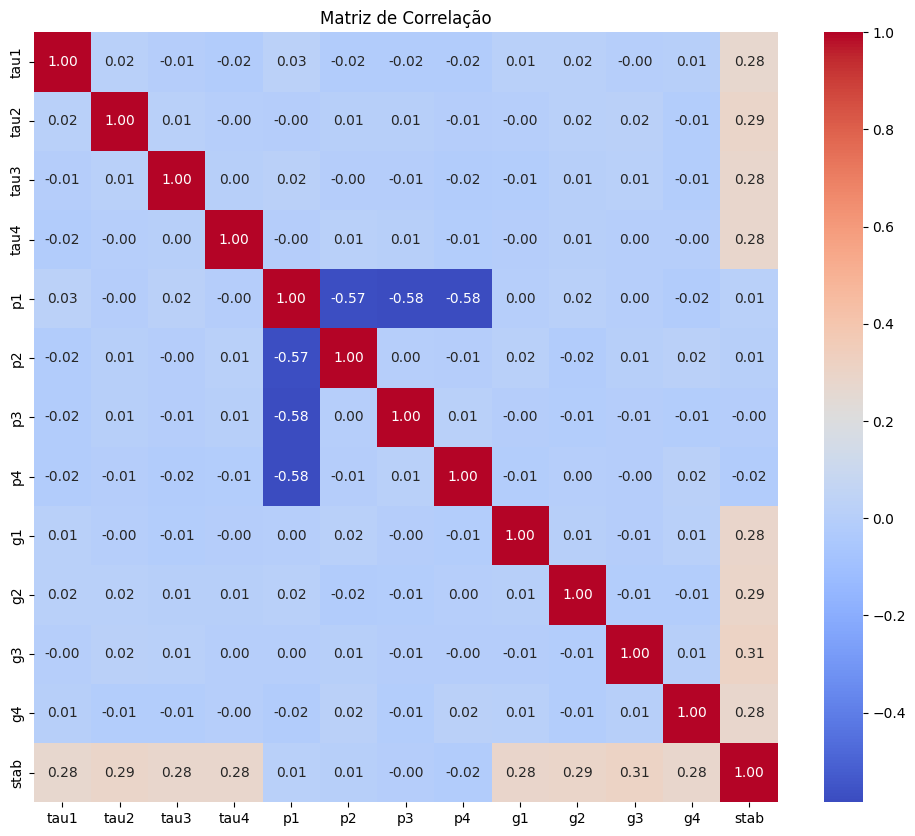

In [95]:
correlation_matrix = dados.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

From the heatmap, we can observe the correlation between 'stab' and other features. Let's select the top 3 features with the highest absolute correlation with 'stab'.

In [96]:
# Get the absolute correlations with 'stab' and sort them
stab_correlations = correlation_matrix['stab'].abs().sort_values(ascending=False)

# Exclude 'stab' itself and select the top 3 features
top_3_features = stab_correlations[1:4].index.tolist()

# Display the top 3 correlated features
print(f"Top 3 features most correlated with 'stab': {top_3_features}")

X = dados[top_3_features]
X.head()

Top 3 features most correlated with 'stab': ['g3', 'g2', 'tau2']


,g3,g2,tau2
0,0.887445,0.859578,3.079885
1,0.562139,0.862414,4.902524
2,0.839444,0.766689,8.848428
3,0.929381,0.976744,7.669600
4,0.656947,0.455450,7.608772


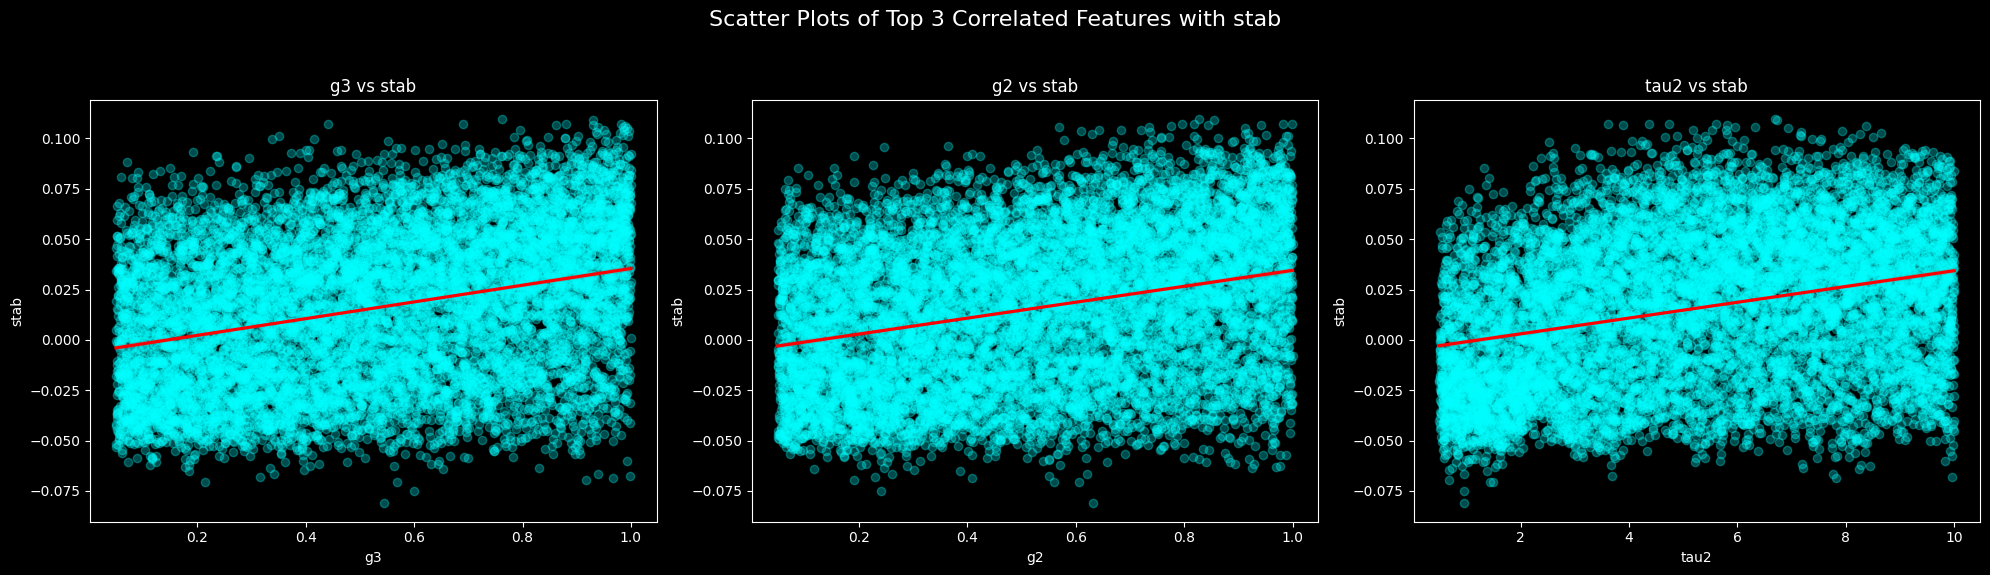

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots for the three scatter plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='black')
fig.suptitle('Scatter Plots of Top 3 Correlated Features with stab', color='white', fontsize=16)

for i, feature in enumerate(top_3_features):
    ax = axes[i]
    sns.regplot(x=dados[feature], y=dados['stab'], ax=ax, scatter_kws={'alpha':0.3, 'color':'cyan'}, line_kws={'color':'red'})
    ax.set_title(f'{feature} vs stab', color='white')
    ax.set_xlabel(feature, color='white')
    ax.set_ylabel('stab', color='white')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    ax.set_facecolor('black') # Set subplot background to black
    ax.spines['bottom'].set_color('white')
    ax.spines['top'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['right'].set_color('white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [102]:
#dados de entrada do modelo (x):
X = dados[['tau2','g2','g3']]
X.head()

,tau2,g2,g3
0,3.079885,0.859578,0.887445
1,4.902524,0.862414,0.562139
2,8.848428,0.766689,0.839444
3,7.669600,0.976744,0.929381
4,7.608772,0.455450,0.656947


In [107]:
#separando dados do modelo regressão linear
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

In [108]:
modelo_LR.fit(X_train, y_train)

LinearRegression()

In [109]:
#gerando previsões
y_predict = modelo_LR.predict(X_test)
y_predict[:50]

array([ 0.02836254,  0.01491935,  0.01758781,  0.00557947, -0.00152692,
        0.00370801,  0.00607375,  0.02169718,  0.0055979 ,  0.01720782,
       -0.00894882,  0.03726513, -0.02117957,  0.0052061 ,  0.03989881,
        0.05255102,  0.02100049,  0.0360181 ,  0.01824608,  0.03023555,
        0.00952129, -0.02415203,  0.02188019,  0.00713168,  0.02055473,
        0.0065953 ,  0.00856773,  0.03413339,  0.01360304, -0.00475366,
        0.01860118,  0.00460138, -0.02415915,  0.01177945,  0.0313005 ,
       -0.02623412,  0.03292247,  0.01925688,  0.0412256 ,  0.01290649,
        0.03636565,  0.02181991, -0.01101281,  0.03839857, -0.00045866,
        0.00047298, -0.01898246,  0.05211772, -0.0036266 ,  0.03484327])

In [111]:
#Metrição
#Coeficiente de determinação R2 (R quadrado)
#MAE: erro médio absoluto
#MSE: erro Médio quadrático
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#

In [112]:

print( f'Coeficiente de determinação R2:{r2_score(y_test, y_predict):.2f}')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_test, y_predict):.2f}')
print(f'Erro médio quadrático (MSE): {mean_squared_error(y_test, y_predict):.2f}')

Coeficiente de determinação R2:0.27
Erro médio absoluto (MAE): 0.03
Erro médio quadrático (MSE): 0.00
